Vision Language Model.  We now want to combine our CV model with the ability to handle natural language prompts as inputs, and add language to the output descriptions.

Example things we may ask a Vision Language Model:

Level 1 — basic visual description
"Describe the visible characteristics of this image."

Level 2 — structured observation
"Describe the lesion's visible color, shape,
border, and apparent symmetry."

Level 3 — domain terminology
"What dermatological visual features are
apparent in this image?"

Level 4 — classification
"Which of these seven HAM10000 categories
best matches the image?"

Level 5 — explanation
"What visual evidence led to that classification?"


Given my small RTX 3050 GPU with only 4 GB of VRAM, we are going to use a small educational Vision Language Model such as SmolVLM2-500M-Video-Instruct. 

## Data Setup

In [5]:
#Setup
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch

In [6]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "metadata_splits.csv"
)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

Device: cuda


In [7]:
#Load metadata
df = pd.read_csv(DATA_PATH)

# Image paths are stored relative to the project root
df["image_path"] = df["image_path"].map(lambda p: str(PROJECT_ROOT / p))

test_df = df[
    df["split"] == "test"
].copy()

print("Test images:", len(test_df))

Test images: 1481


Image ID: ISIC_0026993
Ground truth: mel


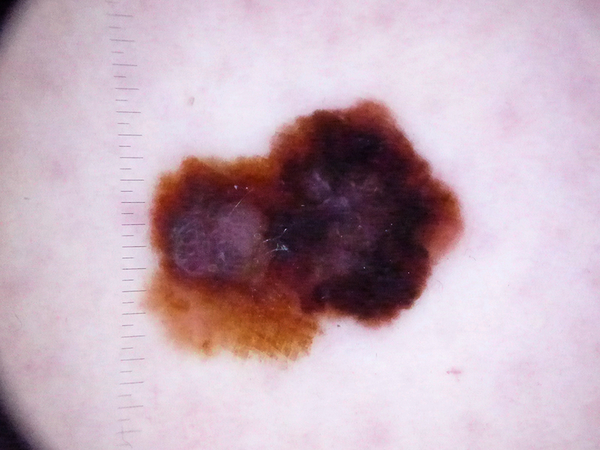

In [8]:
#Grab sample image
IMAGE_ID = "ISIC_0026993"

sample = test_df[
    test_df["image_id"] == IMAGE_ID
].iloc[0]

image = Image.open(
    sample["image_path"]
).convert("RGB")

print("Image ID:", sample["image_id"])
print("Ground truth:", sample["dx"])

image

## Install VLM from Huggingface

Lets start with the smallest VLM model that can do text and images, MODEL_ID = "HuggingFaceTB/SmolVLM-256M-Instruct".  It's small (1 GB or so) but good enough for demonstrating the workflow.  We may move up to 500M model for comparison later.

https://huggingface.co/HuggingFaceTB/SmolVLM-256M-Instruct

In [9]:
import transformers

print("Transformers:", transformers.__version__)

Transformers: 5.17.0


In [10]:
import transformers
import accelerate

from transformers import (
    AutoProcessor,
    AutoModelForMultimodalLM,
)

print("Transformers:", transformers.__version__)
print("Accelerate:", accelerate.__version__)

Transformers: 5.17.0
Accelerate: 1.15.0


We now need to download the Processor and the Model.  The processor converts human instructions into tensors which can then be fed into the neural network model.

In this case of a VLM, the processor needs to process and prep the image and also be a tokenizer for text.  

Note that both processor and model share the same Model_ID because they are linked, and need to be on the same sheet of music for how they share and exchange info and tensors.

In [11]:
MODEL_ID = "HuggingFaceTB/SmolVLM-256M-Instruct"

In [12]:
#Load the processor
processor = AutoProcessor.from_pretrained(
    MODEL_ID
)

print(type(processor))

[transformers] Model config: pad_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 128002. This may result in unexpected behavior.


<class 'transformers.models.idefics3.processing_idefics3.Idefics3Processor'>


In [13]:
#Also download the MODEL, and put the whole thing on GPU
vlm = (
    AutoModelForMultimodalLM
    .from_pretrained(
        MODEL_ID,
        torch_dtype=torch.float16,
    )
    .to(device)
)

vlm.eval()

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/471 [00:00<?, ?it/s]

Idefics3ForConditionalGeneration(
  (model): Idefics3Model(
    (vision_model): Idefics3VisionTransformer(
      (embeddings): Idefics3VisionEmbeddings(
        (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16), padding=valid)
        (position_embedding): Embedding(1024, 768)
      )
      (encoder): Idefics3Encoder(
        (layers): ModuleList(
          (0-11): 12 x Idefics3EncoderLayer(
            (self_attn): Idefics3VisionAttention(
              (k_proj): Linear(in_features=768, out_features=768, bias=True)
              (v_proj): Linear(in_features=768, out_features=768, bias=True)
              (q_proj): Linear(in_features=768, out_features=768, bias=True)
              (out_proj): Linear(in_features=768, out_features=768, bias=True)
            )
            (layer_norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
            (mlp): Idefics3VisionMLP(
              (activation_fn): GELUTanh()
              (fc1): Linear(in_featur

In [14]:
#Confirm model 
print(
    "Model:",
    type(vlm).__name__
)

print(
    "Device:",
    next(vlm.parameters()).device
)

print(
    "Dtype:",
    next(vlm.parameters()).dtype
)

Model: Idefics3ForConditionalGeneration
Device: cuda:0
Dtype: torch.float16


## Use VLM

In [15]:
#Create message we want to feed into VLM
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
            },
            {
                "type": "text",
                "text": (
                    "Describe the visible "
                    "characteristics of this image."
                ),
            },
        ],
    }
]

In [16]:
#Create prompt
prompt = processor.apply_chat_template(
    messages,
    add_generation_prompt=True,
)

print(prompt)

<|im_start|>User:<image>Describe the visible characteristics of this image.<end_of_utterance>
Assistant:


In [17]:
#Now create the model input, combinign the text prompt and image
inputs = processor(
    text=prompt,
    images=[image],
    return_tensors="pt",
).to(device)

In [18]:
#Inspect inputs before generating anything
#inputs is a dictionary containing the processed text and image data for the model
#keys are typically "input_ids", "attention_mask", and "pixel_values" 
# for the processed text and image data
#values are the actual tensors containing the processed data for each key
for key, value in inputs.items():
    #Print any tensor-like objects with shape information
    if hasattr(value, "shape"):
        print(
            key,
            value.shape,
            value.dtype,
            value.device,
        )

input_ids torch.Size([1, 878]) torch.int64 cuda:0
attention_mask torch.Size([1, 878]) torch.int64 cuda:0
pixel_values torch.Size([1, 13, 3, 512, 512]) torch.float32 cuda:0
pixel_attention_mask torch.Size([1, 13, 512, 512]) torch.float32 cuda:0


In [19]:
list(inputs.keys())

['input_ids', 'attention_mask', 'pixel_values', 'pixel_attention_mask']

The 1x878 tensors represent the tokens from the language portion of VLM. 

In [20]:
#Print input tokens
print(inputs["input_ids"][0, :50])

tensor([    1, 11126,    42, 49189, 49153, 49190, 49190, 49190, 49190, 49190,
        49190, 49190, 49190, 49190, 49190, 49190, 49190, 49190, 49190, 49190,
        49190, 49190, 49190, 49190, 49190, 49190, 49190, 49190, 49190, 49190,
        49190, 49190, 49190, 49190, 49190, 49190, 49190, 49190, 49190, 49190,
        49190, 49190, 49190, 49190, 49190, 49190, 49190, 49190, 49190, 49190],
       device='cuda:0')


In [21]:
#Decode input tokens
print(
    processor.tokenizer.decode(
        inputs["input_ids"][0]
    )
)

<|im_start|>User:<fake_token_around_image><row_1_col_1><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><fake_token_around_image><row_1_col_2><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><image><fake_token

In [22]:
#Attention mask tokens
print(
    torch.unique(
        inputs["attention_mask"]
    )
)

tensor([1], device='cuda:0')


Why the `[1, 13, 3, 512, 512]` size for image tensors?  The Smol model's image processor creates 13 different 512x512 cropped images from the original image, giving it more views to ensure it doesn't lose any information when resizing image.  

New lets generate with our model!

In [23]:
with torch.no_grad():
    generated_ids = vlm.generate(
        **inputs,
        max_new_tokens=100,
    )

In [24]:
#Inspect
print(
    "Input tokens:",
    inputs["input_ids"].shape
)

print(
    "Generated shape:",
    generated_ids.shape
)

Input tokens: torch.Size([1, 878])
Generated shape: torch.Size([1, 978])


Note that it genreated 100 extra tokesn, which matches the `max_new_tokens=100` we specified.

In [25]:
#Grab just the new reponse
input_length = inputs["input_ids"].shape[1]

print(input_length)

878


In [26]:
new_tokens = generated_ids[
    :,
    input_length:
]

print(
    "New tokens:",
    new_tokens.shape
)

New tokens: torch.Size([1, 100])


In [27]:
#Decode just the new response tokens
response = processor.batch_decode(
    new_tokens,
    skip_special_tokens=True,
)[0]

print(response)

 The image depicts a close-up view of a small, dark brown object that appears to be a tumor or a mass. The object is located in the center of the image and is surrounded by a white, light-colored surface. The object has a rough, irregular surface with a few small, dark spots scattered throughout its surface. The dark spots are irregular and appear to be irregularly shaped, possibly due to the tumor's growth or the presence of a tumor marker.

The background of


Note that model attempts to make some interpretations and medical judgments.  Let's refine the prompt to avoid that.

In [28]:
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
            },
            {
                "type": "text",
                "text": (
                    "Describe only the directly visible "
                    "characteristics of the lesion. "
                    "Describe its color, shape, border, "
                    "surface appearance, and symmetry. "
                    "Do not provide a diagnosis or speculate "
                    "about causes."
                ),
            },
        ],
    }
]

In [29]:
with torch.no_grad():
    generated_ids = vlm.generate(
        **inputs,
        max_new_tokens=150,
    )

In [30]:
input_length = inputs["input_ids"].shape[1]

new_tokens = generated_ids[
    :,
    input_length:
]

response = processor.batch_decode(
    new_tokens,
    skip_special_tokens=True,
)[0]

print(response)

 The image depicts a close-up view of a small, dark brown object that appears to be a tumor or a mass. The object is located in the center of the image and is surrounded by a white, light-colored surface. The object has a rough, irregular surface with a few small, dark spots scattered throughout its surface. The dark spots are irregular and appear to be irregularly shaped, possibly due to the tumor's growth or the presence of a tumor marker.

The background of the image is a light-colored surface, likely white or light pink, which contrasts with the dark brown object and the white surface. The lighting in the image is soft and even, with no harsh shadows or highlights, which helps to highlight the dark


## Using VLM to classify
So far we have used the VLM to get text descriptions of the images.  Let's see if we can use the model to classify the images.  That is, see if we can "zero-shot" the model for our classification task.

In [31]:
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
            },
            {
                "type": "text",
                "text": (
                    "Classify this skin lesion into exactly "
                    "one of the following categories:\n"
                    "akiec, bcc, bkl, df, mel, nv, vasc.\n\n"
                    "Return only the category abbreviation."
                ),
            },
        ],
    }
]

In [32]:
prompt = processor.apply_chat_template(
    messages,
    add_generation_prompt=True,
)

inputs = processor(
    text=prompt,
    images=[image],
    return_tensors="pt",
).to(device)

In [33]:
with torch.no_grad():
    generated_ids = vlm.generate(
        **inputs,
        max_new_tokens=10,
    )

input_length = inputs["input_ids"].shape[1]

new_tokens = generated_ids[
    :,
    input_length:
]

response = processor.batch_decode(
    new_tokens,
    skip_special_tokens=True,
)[0]

print("Ground truth:", sample["dx"])
print("VLM prediction:", response)

Ground truth: mel
VLM prediction:  Bcc.


Initial reponse is wrong, which is not surprising since we didn't even explain what the abbreviations mean, or how to identify them. 

In [34]:
prediction = (
    response
    .strip()
    .lower()
    .replace(".", "")
)

print(prediction)

bcc


In [35]:
#See if it helps to give full description of classes
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
            },
            {
                "type": "text",
                "text": (
                    "Classify this skin lesion into exactly "
                    "one of the following categories:\n\n"
                    "akiec = actinic keratoses and "
                    "intraepithelial carcinoma\n"
                    "bcc = basal cell carcinoma\n"
                    "bkl = benign keratosis-like lesions\n"
                    "df = dermatofibroma\n"
                    "mel = melanoma\n"
                    "nv = melanocytic nevus\n"
                    "vasc = vascular lesions\n\n"
                    "Return only the category abbreviation."
                ),
            },
        ],
    }
]

In [36]:
prompt = processor.apply_chat_template(
    messages,
    add_generation_prompt=True,
)

inputs = processor(
    text=prompt,
    images=[image],
    return_tensors="pt",
).to(device)

with torch.no_grad():
    generated_ids = vlm.generate(
        **inputs,
        max_new_tokens=10,
    )

input_length = inputs["input_ids"].shape[1]

new_tokens = generated_ids[:, input_length:]

response = processor.batch_decode(
    new_tokens,
    skip_special_tokens=True,
)[0]

print("Ground truth:", sample["dx"])
print("VLM prediction:", response)

Ground truth: mel
VLM prediction:  Bkl.


## Experiment on 35 images, 5 from each class.

In [37]:
SAMPLES_PER_CLASS = 5
RANDOM_SEED = 42

vlm_sample_df = (
    test_df
    .groupby(
        "dx",
        group_keys=False,
    )
    .sample(
        n=SAMPLES_PER_CLASS,
        random_state=RANDOM_SEED,
    )
    .reset_index(drop=True)
)

print(
    vlm_sample_df["dx"]
    .value_counts()
    .sort_index()
)

dx
akiec    5
bcc      5
bkl      5
df       5
mel      5
nv       5
vasc     5
Name: count, dtype: int64


In [38]:
classification_prompt = (
    "Classify this skin lesion into exactly "
    "one of the following categories:\n\n"
    "akiec = actinic keratoses and "
    "intraepithelial carcinoma\n"
    "bcc = basal cell carcinoma\n"
    "bkl = benign keratosis-like lesions\n"
    "df = dermatofibroma\n"
    "mel = melanoma\n"
    "nv = melanocytic nevus\n"
    "vasc = vascular lesions\n\n"
    "Return only the category abbreviation."
)

In [39]:
#Function to classify a skin lesion image using the vision-language model
def classify_with_vlm(
    image_path,
    model,
    processor,
    device,
):
    image = Image.open(
        image_path
    ).convert("RGB")

    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": image,
                },
                {
                    "type": "text",
                    "text": classification_prompt,
                },
            ],
        }
    ]

    inputs = processor.apply_chat_template(
        messages,
        add_generation_prompt=True,
        tokenize=True,
        return_dict=True,
        return_tensors="pt",
    ).to(device)

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=10,
        )

    input_length = inputs[
        "input_ids"
    ].shape[1]

    new_tokens = generated_ids[
        :,
        input_length:
    ]

    response = processor.batch_decode(
        new_tokens,
        skip_special_tokens=True,
    )[0]

    prediction = (
        response
        .strip()
        .lower()
        .replace(".", "")
    )

    return prediction
# def classify_with_vlm(
#     image_path,
#     model,
#     processor,
#     device,
# ):
#     image = Image.open(
#         image_path
#     ).convert("RGB")

#     messages = [
#         {
#             "role": "user",
#             "content": [
#                 {"type": "image"},
#                 {
#                     "type": "text",
#                     "text": classification_prompt,
#                 },
#             ],
#         }
#     ]

#     prompt = processor.apply_chat_template(
#         messages,
#         add_generation_prompt=True,
#     )

#     inputs = processor(
#         text=prompt,
#         images=[image],
#         return_tensors="pt",
#     ).to(device)

#     with torch.no_grad():
#         generated_ids = model.generate(
#             **inputs,
#             max_new_tokens=10,
#         )

#     input_length = inputs[
#         "input_ids"
#     ].shape[1]

#     new_tokens = generated_ids[
#         :,
#         input_length:
#     ]

#     response = processor.batch_decode(
#         new_tokens,
#         skip_special_tokens=True,
#     )[0]

#     prediction = (
#         response
#         .strip()
#         .lower()
#         .replace(".", "")
#     )

#     return prediction

In [40]:
test_prediction = classify_with_vlm(
    sample["image_path"],
    vlm,
    processor,
    device,
)

print(test_prediction)

bkl


In [41]:
VALID_CLASSES = {
    "akiec",
    "bcc",
    "bkl",
    "df",
    "mel",
    "nv",
    "vasc",
}

In [42]:
import time

In [43]:
#Run 35 images
results = []

start_time = time.perf_counter()

for i, row in vlm_sample_df.iterrows():
    image_start = time.perf_counter()

    prediction = classify_with_vlm(
        row["image_path"],
        vlm,
        processor,
        device,
    )

    image_time = (
        time.perf_counter()
        - image_start
    )

    valid_output = (
        prediction in VALID_CLASSES
    )

    results.append({
        "image_id": row["image_id"],
        "true_class": row["dx"],
        "vlm_prediction": prediction,
        "valid_output": valid_output,
        "inference_seconds": image_time,
    })

    print(
        f"{i + 1:2d}/"
        f"{len(vlm_sample_df)} | "
        f"true={row['dx']:5s} | "
        f"pred={prediction:10s} | "
        f"{image_time:.2f}s"
    )

total_time = time.perf_counter() - start_time

vlm_results_df = pd.DataFrame(results)

 1/35 | true=akiec | pred=nv         | 0.38s
 2/35 | true=akiec | pred=nv         | 0.26s
 3/35 | true=akiec | pred=bkl        | 0.33s
 4/35 | true=akiec | pred=nv         | 0.29s
 5/35 | true=akiec | pred=nv         | 0.35s
 6/35 | true=bcc   | pred=bkl        | 0.25s
 7/35 | true=bcc   | pred=nv         | 0.20s
 8/35 | true=bcc   | pred=bkl        | 0.45s
 9/35 | true=bcc   | pred=nv         | 0.55s
10/35 | true=bcc   | pred=bkl        | 0.47s
11/35 | true=bkl   | pred=nv         | 0.42s
12/35 | true=bkl   | pred=bkl        | 0.39s
13/35 | true=bkl   | pred=bcc = basal cell carcinoma | 0.52s
14/35 | true=bkl   | pred=bkl = benign keratosis-like lesions | 0.59s
15/35 | true=bkl   | pred=bkl        | 0.49s
16/35 | true=df    | pred=melanocytic nevus | 0.57s
17/35 | true=df    | pred=bkl        | 0.54s
18/35 | true=df    | pred=nv         | 0.49s
19/35 | true=df    | pred=bkl        | 0.43s
20/35 | true=df    | pred=nv         | 0.40s
21/35 | true=mel   | pred=nv         | 0.45s
22/35 |

In [44]:
print(
    f"Total time: {total_time:.1f} seconds"
)

print(
    f"Average per image: "
    f"{vlm_results_df['inference_seconds'].mean():.2f} seconds"
)

print(
    "\nInvalid outputs:",
    (~vlm_results_df["valid_output"]).sum()
)

Total time: 16.9 seconds
Average per image: 0.48 seconds

Invalid outputs: 5


In [45]:
print(
    vlm_results_df[
        ~vlm_results_df["valid_output"]
    ][
        [
            "image_id",
            "true_class",
            "vlm_prediction",
        ]
    ]
)

        image_id true_class                       vlm_prediction
12  ISIC_0027820        bkl           bcc = basal cell carcinoma
13  ISIC_0033646        bkl  bkl = benign keratosis-like lesions
15  ISIC_0027107         df                    melanocytic nevus
23  ISIC_0033444        mel                    melanocytic nevus
34  ISIC_0026713       vasc                    melanocytic nevus


In [46]:
#Get accuracy
vlm_accuracy = (
    vlm_results_df["true_class"]
    ==
    vlm_results_df["vlm_prediction"]
).mean()

print(
    f"VLM zero-shot accuracy: "
    f"{vlm_accuracy:.3f}"
)

VLM zero-shot accuracy: 0.143


In [47]:
per_class_results = (
    vlm_results_df
    .assign(
        correct=lambda x:
            x["true_class"]
            == x["vlm_prediction"]
    )
    .groupby("true_class")
    .agg(
        correct=("correct", "sum"),
        total=("correct", "count"),
    )
)

per_class_results["accuracy"] = (
    per_class_results["correct"]
    /
    per_class_results["total"]
)

per_class_results

,correct,total,accuracy
true_class,,,
akiec,0,5,0.0
bcc,0,5,0.0
bkl,2,5,0.4
df,0,5,0.0
mel,0,5,0.0
nv,3,5,0.6
vasc,0,5,0.0


In [48]:
#Account for fact that it got some predictions correct, but labeled them wrong
OUTPUT_NORMALIZATION = {
    "bcc = basal cell carcinoma": "bcc",
    "bkl = benign keratosis-like lesions": "bkl",
    "melanocytic nevus": "nv",
}

vlm_results_df["normalized_prediction"] = (
    vlm_results_df["vlm_prediction"]
    .replace(OUTPUT_NORMALIZATION)
)

vlm_results_df["normalized_correct"] = (
    vlm_results_df["true_class"]
    ==
    vlm_results_df["normalized_prediction"]
)

normalized_accuracy = (
    vlm_results_df["normalized_correct"].mean()
)

print(
    f"Strict accuracy: "
    f"{vlm_accuracy:.3f}"
)

print(
    f"Semantically normalized accuracy: "
    f"{normalized_accuracy:.3f}"
)

Strict accuracy: 0.143
Semantically normalized accuracy: 0.171


Results: 250M model is no better than random at zero-shot classifying images by category, though is able to follow simple instructions and format responses.

## Bigger 500M model

In [49]:
MODEL_ID_500M = (
    "HuggingFaceTB/"
    "SmolVLM2-500M-Video-Instruct"
)

In [50]:
processor_500m = AutoProcessor.from_pretrained(
    MODEL_ID_500M
)

In [51]:
from transformers import AutoProcessor, AutoModelForImageTextToText

In [52]:
vlm_500m = (
    AutoModelForImageTextToText
    .from_pretrained(
        MODEL_ID_500M,
        torch_dtype=torch.float16,
    )
    .to(device)
)

vlm_500m.eval()

Loading weights:   0%|          | 0/489 [00:00<?, ?it/s]

SmolVLMForConditionalGeneration(
  (model): SmolVLMModel(
    (vision_model): SmolVLMVisionTransformer(
      (embeddings): SmolVLMVisionEmbeddings(
        (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16), padding=valid)
        (position_embedding): Embedding(1024, 768)
      )
      (encoder): SmolVLMEncoder(
        (layers): ModuleList(
          (0-11): 12 x SmolVLMEncoderLayer(
            (self_attn): SmolVLMVisionAttention(
              (k_proj): Linear(in_features=768, out_features=768, bias=True)
              (v_proj): Linear(in_features=768, out_features=768, bias=True)
              (q_proj): Linear(in_features=768, out_features=768, bias=True)
              (out_proj): Linear(in_features=768, out_features=768, bias=True)
            )
            (layer_norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True, bias=True)
            (mlp): SmolVLMVisionMLP(
              (activation_fn): GELUTanh()
              (fc1): Linear(in_features=768, 

In [53]:
#Check on GPU usage
print(
    "Allocated:",
    f"{torch.cuda.memory_allocated() / 1024**3:.2f} GB"
)

print(
    "Reserved:",
    f"{torch.cuda.memory_reserved() / 1024**3:.2f} GB"
)

Allocated: 1.54 GB
Reserved: 1.57 GB


In [54]:
# #If needed, dump old vlm model
# del vlm

# torch.cuda.empty_cache()

In [55]:
print(
    "Model:",
    type(vlm_500m).__name__
)

print(
    "Device:",
    next(vlm_500m.parameters()).device
)

print(
    "Dtype:",
    next(vlm_500m.parameters()).dtype
)

print(
    "Allocated GPU memory:",
    f"{torch.cuda.memory_allocated() / 1024**3:.2f} GB"
)

Model: SmolVLMForConditionalGeneration
Device: cuda:0
Dtype: torch.float16
Allocated GPU memory: 1.54 GB


In [56]:
test_prediction_500m = classify_with_vlm(
    sample["image_path"],
    vlm_500m,
    processor_500m,
    device,
)

print("Ground truth:", sample["dx"])
print(
    "256M prediction:",
    "bkl",
)

print(
    "500M prediction:",
    test_prediction_500m,
)

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


Ground truth: mel
256M prediction: bkl
500M prediction: bkl


In [57]:
import time

In [58]:
#Run 35 image test
results_500m = []

start_time = time.perf_counter()

for i, row in vlm_sample_df.iterrows():
    image_start = time.perf_counter()

    prediction = classify_with_vlm(
        row["image_path"],
        vlm_500m,
        processor_500m,
        device,
    )

    image_time = (
        time.perf_counter()
        - image_start
    )

    valid_output = (
        prediction in VALID_CLASSES
    )

    results_500m.append({
        "image_id": row["image_id"],
        "true_class": row["dx"],
        "vlm_prediction": prediction,
        "valid_output": valid_output,
        "inference_seconds": image_time,
    })

    print(
        f"{i + 1:2d}/"
        f"{len(vlm_sample_df)} | "
        f"true={row['dx']:5s} | "
        f"pred={prediction:20s} | "
        f"{image_time:.2f}s"
    )

total_time_500m = (
    time.perf_counter()
    - start_time
)

vlm_500m_results_df = pd.DataFrame(
    results_500m
)

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


 1/35 | true=akiec | pred=bkl                  | 0.53s


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


 2/35 | true=akiec | pred=akiec                | 0.57s


...

32/35 | true=vasc  | pred=akiec                | 0.51s


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


33/35 | true=vasc  | pred=akiec                | 0.40s


[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


34/35 | true=vasc  | pred=bkl                  | 0.39s
35/35 | true=vasc  | pred=akiec                | 0.45s


In [59]:
strict_accuracy_500m = (
    vlm_500m_results_df["true_class"]
    ==
    vlm_500m_results_df["vlm_prediction"]
).mean()

print(
    f"Total time: "
    f"{total_time_500m:.1f} seconds"
)

print(
    f"Average per image: "
    f"{vlm_500m_results_df['inference_seconds'].mean():.2f} seconds"
)

print(
    "Invalid outputs:",
    (~vlm_500m_results_df["valid_output"]).sum()
)

print(
    f"Strict accuracy: "
    f"{strict_accuracy_500m:.3f}"
)

Total time: 16.2 seconds
Average per image: 0.46 seconds
Invalid outputs: 0
Strict accuracy: 0.114


In [60]:
prediction_counts_500m = (
    vlm_500m_results_df[
        "vlm_prediction"
    ]
    .value_counts()
    .reindex(
        sorted(VALID_CLASSES),
        fill_value=0,
    )
)

prediction_counts_500m

vlm_prediction
akiec    27
bcc       0
bkl       8
df        0
mel       0
nv        0
vasc      0
Name: count, dtype: int64

In [61]:
per_class_500m = (
    vlm_500m_results_df
    .assign(
        correct=lambda x:
            x["true_class"]
            == x["vlm_prediction"]
    )
    .groupby("true_class")
    .agg(
        correct=("correct", "sum"),
        total=("correct", "count"),
    )
)

per_class_500m["accuracy"] = (
    per_class_500m["correct"]
    /
    per_class_500m["total"]
)

per_class_500m

,correct,total,accuracy
true_class,,,
akiec,4,5,0.8
bcc,0,5,0.0
bkl,0,5,0.0
df,0,5,0.0
mel,0,5,0.0
nv,0,5,0.0
vasc,0,5,0.0


Overall, 500M is better at instruction following, and it has concentrated its predictions more than the 250M model (though still not very accurate).

In [62]:
torch.cuda.memory_allocated()

1654885376

In [63]:
#Also check out PEAK memory usage during inference
torch.cuda.reset_peak_memory_stats()

prediction = classify_with_vlm(
    sample["image_path"],
    vlm_500m,
    processor_500m,
    device,
)

peak = (
    torch.cuda.max_memory_allocated()
    / 1024**3
)

print(f"Peak allocated: {peak:.2f} GB")
print(f"Current allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

[transformers] Kwargs passed to `processor.__call__` have to be in `processor_kwargs` dict, not in `**kwargs`


Peak allocated: 1.86 GB
Current allocated: 1.54 GB


Stage 6 Conclusions.

500M followed the requested output format better, but did not demonstrate better zero-shot dermatology classification.

A general-purpose VLM provides flexible image-language interaction but showed poor zero-shot performance on the specialized HAM10000 classification task. Increasing model size from 256M to 500M did not improve classification on the fixed 35-image balanced sample. The 500M model improved output-format compliance but exhibited severe prediction bias, assigning 27/35 images to akiec.


In [64]:
#Save humna readable text artifact
from pathlib import Path

RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

example_row = vlm_500m_results_df.iloc[0]

example_image_id = example_row["image_id"]
example_true_class = example_row["true_class"]
example_prediction = example_row["vlm_prediction"]

example_text = f"""Stage 6 — Zero-Shot VLM Example

Model:
{MODEL_ID_500M}

Image ID:
{example_image_id}

Ground-truth HAM10000 class:
{example_true_class}

Prompt:
{classification_prompt}

Raw model output:
{example_prediction}

Experiment:
Zero-shot classification. The model was not fine-tuned on HAM10000.

Note:
This example is part of an educational/research experiment and is not
intended for clinical diagnosis.
"""

output_path = (
    RESULTS_DIR
    / "stage6_vlm_example.txt"
)

output_path.write_text(
    example_text,
    encoding="utf-8",
)

print(f"Saved to: {output_path}")

Saved to: /mnt/c/Users/Sarah/SMcurrentprojects/SM_skinlesionsAI/skin-lesion-ai/results/stage6_vlm_example.txt


In [65]:
print(
    output_path.read_text(
        encoding="utf-8"
    )
)

Stage 6 — Zero-Shot VLM Example

Model:
HuggingFaceTB/SmolVLM2-500M-Video-Instruct

Image ID:
ISIC_0025368

Ground-truth HAM10000 class:
akiec

Prompt:
Classify this skin lesion into exactly one of the following categories:

akiec = actinic keratoses and intraepithelial carcinoma
bcc = basal cell carcinoma
bkl = benign keratosis-like lesions
df = dermatofibroma
mel = melanoma
nv = melanocytic nevus
vasc = vascular lesions

Return only the category abbreviation.

Raw model output:
bkl

Experiment:
Zero-shot classification. The model was not fine-tuned on HAM10000.

Note:
This example is part of an educational/research experiment and is not
intended for clinical diagnosis.



In [66]:
DESCRIPTION_IMAGE_ID = "ISIC_0026993"

description_prompt = (
    "Describe only the directly visible characteristics "
    "of the lesion. Describe its color, shape, border, "
    "surface appearance, and symmetry. Do not provide a "
    "diagnosis or speculate about causes."
)

description_response = """The image depicts a close-up view of a small, dark brown object that appears to be a tumor or a mass. The object is located in the center of the image and is surrounded by a white, light-colored surface. The object has a rough, irregular surface with a few small, dark spots scattered throughout its surface. The dark spots are irregular and appear to be irregularly shaped, possibly due to the tumor's growth or the presence of a tumor marker. The background of the image is a light-colored surface, likely white or light pink, ..."""

In [67]:
description_artifact = f"""Stage 6 — VLM Visual Description Example

Model:
HuggingFaceTB/SmolVLM-256M-Instruct

Image ID:
{DESCRIPTION_IMAGE_ID}

Ground-truth HAM10000 class:
mel

Prompt:
{description_prompt}

Raw model output:
{description_response}

Observation:
The prompt explicitly instructed the model to describe only directly
visible characteristics and not provide a diagnosis or speculate about
causes.

Despite this instruction, the model introduced unsupported medical
language such as "tumor," "tumor growth," and "tumor marker."

This demonstrates an important limitation of general-purpose VLMs:
natural-language responses can sound plausible while including claims
that are not grounded in the image or available annotations.

This example is part of an educational/research experiment and is not
intended for clinical diagnosis.
"""

description_output_path = (
    RESULTS_DIR
    / "stage6_vlm_description_example.txt"
)

description_output_path.write_text(
    description_artifact,
    encoding="utf-8",
)

print(
    f"Saved to: "
    f"{description_output_path}"
)

Saved to: /mnt/c/Users/Sarah/SMcurrentprojects/SM_skinlesionsAI/skin-lesion-ai/results/stage6_vlm_description_example.txt


In [68]:
print(
    description_output_path.read_text(
        encoding="utf-8"
    )
)

Stage 6 — VLM Visual Description Example

Model:
HuggingFaceTB/SmolVLM-256M-Instruct

Image ID:
ISIC_0026993

Ground-truth HAM10000 class:
mel

Prompt:
Describe only the directly visible characteristics of the lesion. Describe its color, shape, border, surface appearance, and symmetry. Do not provide a diagnosis or speculate about causes.

Raw model output:
The image depicts a close-up view of a small, dark brown object that appears to be a tumor or a mass. The object is located in the center of the image and is surrounded by a white, light-colored surface. The object has a rough, irregular surface with a few small, dark spots scattered throughout its surface. The dark spots are irregular and appear to be irregularly shaped, possibly due to the tumor's growth or the presence of a tumor marker. The background of the image is a light-colored surface, likely white or light pink, ...

Observation:
The prompt explicitly instructed the model to describe only directly
visible characteristics 